# 컨벌루션 및 맥스풀링

In [1]:
from tensorflow.keras.datasets import mnist
import matplotlib.pyplot as plt

(x_train, t_train), (x_test, t_test) = mnist.load_data()

In [2]:
x_train.shape, t_train.shape, x_test.shape, t_test.shape

((60000, 28, 28), (60000,), (10000, 28, 28), (10000,))

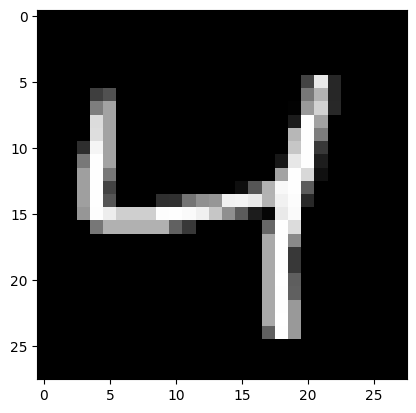

In [3]:
plt.imshow(x_train[2], cmap='gray')

In [4]:
import numpy as np

horizontal_filter = np.array([[1.,1.,1.],
                              [0.,0.,0.],
                              [-1.,-1.,-1.]])
vertical_filter = np.array([[1.,0.,-1.],
                            [1.,0.,-1.], 
                            [1.,0.,-1.]])

In [5]:
test_image = x_train[2]
original_image_size = test_image.shape[0] # test_image.shape : (28, 28)
print("original_image_size =", original_image_size)
conv_output_size = int((original_image_size - 3)/1+1)
print('output size = ', conv_output_size)

original_image_size = 28
output size =  26


In [6]:
filter_size = 3

def get_conv_image(filter):
    filtered_image = np.zeros((conv_output_size, conv_output_size))
    for i in range(conv_output_size):
        for j in range(conv_output_size):
            indice_image = test_image[i:(i+filter_size), j:(j+filter_size)] * filter
            indice_sum = np.sum(indice_image)
            if (indice_sum > 255):
                indice_sum = 255
            
            filtered_image[i,j] = indice_sum

    return filtered_image

In [7]:
vertical_filtered_image = get_conv_image(vertical_filter)
horizontal_filtered_image = get_conv_image(horizontal_filter)

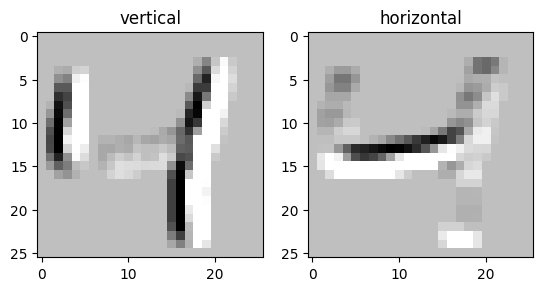

In [8]:
plt.subplot(1,2,1)
plt.title('vertical')
plt.imshow(vertical_filtered_image, cmap='gray')

plt.subplot(1,2,2)
plt.title('horizontal')
plt.imshow(horizontal_filtered_image, cmap='gray')
plt.show()

In [9]:
sobel_image = np.sqrt(np.square(horizontal_filtered_image) + np.square(vertical_filtered_image))

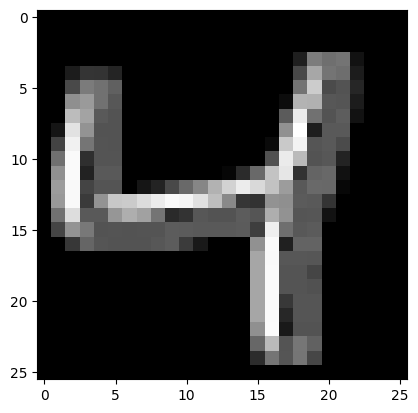

In [10]:
plt.imshow(sobel_image, cmap='gray')

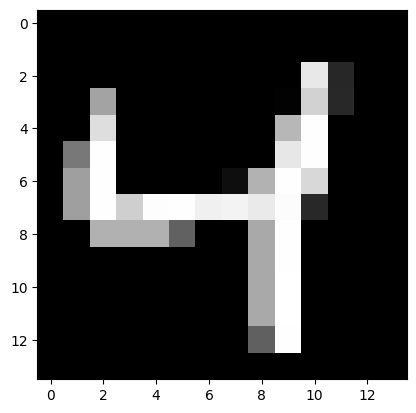

In [11]:
import numpy as np

image = x_train[2]
image_x = image.shape[0]
image_y = image.shape[1]

new_image_x = int(image_x / 2)
new_image_y = int(image_y / 2)

pooled_image = np.zeros((new_image_x, new_image_y))
for x in range(0, image_x, 2):
    for y in range(0, image_y, 2):
        pooled_image[int(x/2), int(y/2)] = np.max(image[x:x+2, y:y+2]) # max pooling

plt.imshow(pooled_image, cmap='gray')

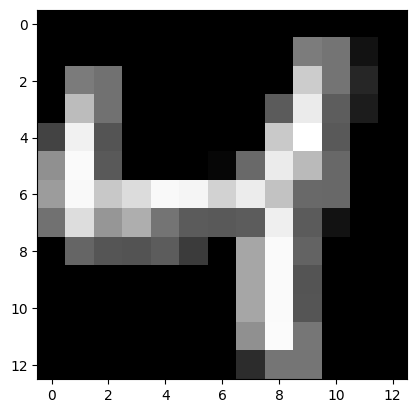

In [12]:
import numpy as np

image = sobel_image
image_x = image.shape[0]
image_y = image.shape[1]

new_image_x = int(image_x / 2)
new_image_y = int(image_y / 2)

pooled_image = np.zeros((new_image_x, new_image_y))
for x in range(0, image_x, 2):
    for y in range(0, image_y, 2):
        pooled_image[int(x/2), int(y/2)] = np.max(image[x:x+2, y:y+2]) # max pooling

plt.imshow(pooled_image, cmap='gray')

# Mnist 데이터 분류 

In [13]:
import tensorflow as tf
from tensorflow.keras import layers
from tensorflow import keras

In [14]:
mnist = tf.keras.datasets.mnist
(x_train, y_train), (x_test, y_test) = mnist.load_data()

In [15]:
x_train, x_test = x_train / 255.0, x_test / 255.0

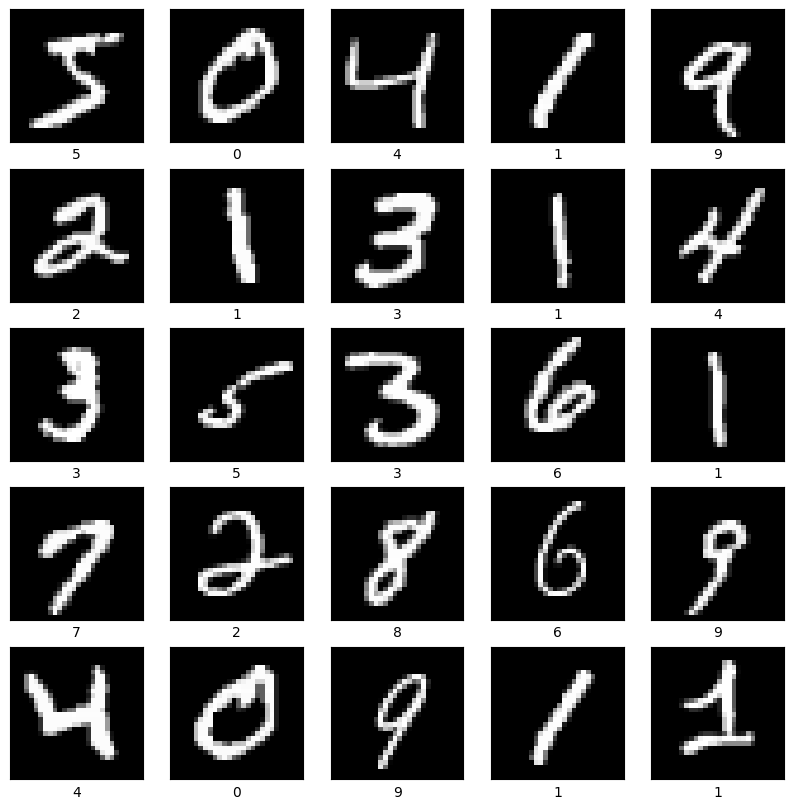

In [16]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,10))
for index in range(25):
    plt.subplot(5,5, index+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(x_train[index], cmap='gray')
    plt.xlabel(str(y_train[index]))
plt.show()

#### Conv2D(16, 3 or (3,3), padding='valid', input_shape=(28, 28, 1), activation='relu')
- 첫번째 인자 : 컨볼루션 필터의 수
- 두번째 인자 : 컨볼루션 커널의 (행, 열) 크기
- padding : 경계 처리 방법 정의.
    - 'valid' : 유효한 영역만 출력.출력 이미지 사이즈는 입력 사이즈보다 작아진다.
    - 'same' : 출력 이미지 사이즈가 입력 이미지 사이즈와 동일하다.
- input_shape : 샘플 수를 제외한 입력 형태 정의. 모델에서 첫 레이어일 때만 정의한다.
    - (행, 열, 채널 수)로 정의한다. 흑백영상인 경우에는 채널이 1이고, 컬러(RGB)영상인 경우에는 채널을 3으로 설정한다.
- activation : 활성화 함수를 설정한다.
    - 'linear' : 입력뉴런과 가중치로 계산된 결과값이 그대로 출력으로 나온다.default=None
    - 'relu' : rectifier 함수, 은닉층에 주로 쓰인다.
    - 'sigmoid' : 시그모이드 함수, 이진 분류 문제에서 출력층에 주로 쓰인다.
    - 'softmax' : 소프트맥스 함수, 다중 클래스 분류 문제에서 출력층에 주로 쓰인다.

In [17]:
model = tf.keras.models.Sequential([
    tf.keras.layers.Reshape((28,28,1)), # 입력형식
    tf.keras.layers.Conv2D(16,3, activation='relu'), # 컨볼루션
    tf.keras.layers.Flatten(), # 컨볼류션한 값을 일차원으로 변환
    tf.keras.layers.Dense(128, activation='relu'), # 은닉층
    tf.keras.layers.Dense(10, activation='softmax') # 출력층
])
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

In [18]:
model.fit(x_train, y_train, epochs=5)

Epoch 1/5


1875/1875 [==============================] - 11s 5ms/step - loss: 0.1489 - accuracy: 0.9550
Epoch 2/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0481 - accuracy: 0.9851
Epoch 3/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0269 - accuracy: 0.9912
Epoch 4/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0175 - accuracy: 0.9943
Epoch 5/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0100 - accuracy: 0.9966


In [19]:
model.evaluate(x_test, y_test, verbose=2)

313/313 - 2s - loss: 0.0616 - accuracy: 0.9842 - 2s/epoch - 5ms/step


[0.06157931685447693, 0.9842000007629395]

In [20]:
model.summary()

Model: "sequential"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 reshape (Reshape)           (None, 28, 28, 1)         0         
                                                                 
 conv2d (Conv2D)             (None, 26, 26, 16)        160       
                                                                 
 flatten (Flatten)           (None, 10816)             0         
                                                                 
 dense (Dense)               (None, 128)               1384576   
                                                                 
 dense_1 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1386026 (5.29 MB)
Trainable params: 1386026 (5.29 MB)
Non-trainable params: 0 (0.00 Byte)
_________________________________________________________________


# Keras API (Sequential vs Functional)

- Tensorflow에서 keras api를 활용하는 방법이 크게 두가지.
- Sequential은 layer의 구조가 순차적으로 있을때 사용이 편리.
- Functional API를 활용한다면 복잡한 구조를 설계할 수 있음
    - 예를 들어서 input, output을 여러개 관리 하거나, layer 사이사이에 연결을 해줄 때.

In [21]:
inputs = keras.Input(shape=(28,28))
x = layers.Reshape((28, 28, 1))(inputs)
x = layers.Conv2D(16,3, activation='relu')(x)
x = layers.Flatten()(x)
x = layers.Dense(128)(x)
x = layers.Dense(10, activation='softmax')(x)
outputs = x

model = keras.Model(inputs, outputs)
model.summary()

Model: "model"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 input_1 (InputLayer)        [(None, 28, 28)]          0         
                                                                 
 reshape_1 (Reshape)         (None, 28, 28, 1)         0         
                                                                 
 conv2d_1 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 flatten_1 (Flatten)         (None, 10816)             0         
                                                                 
 dense_2 (Dense)             (None, 128)               1384576   
                                                                 
 dense_3 (Dense)             (None, 10)                1290      
                                                                 
Total params: 1386026 (5.29 MB)
Trainable params: 1386026 (5.

In [22]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5, verbose=2)
model.evaluate(x_test, y_test, verbose=0)

Epoch 1/5
1875/1875 - 9s - loss: 0.1457 - accuracy: 0.9564 - 9s/epoch - 5ms/step
Epoch 2/5
1875/1875 - 8s - loss: 0.0652 - accuracy: 0.9801 - 8s/epoch - 4ms/step
Epoch 3/5
1875/1875 - 8s - loss: 0.0474 - accuracy: 0.9852 - 8s/epoch - 4ms/step
Epoch 4/5
1875/1875 - 8s - loss: 0.0336 - accuracy: 0.9893 - 8s/epoch - 4ms/step
Epoch 5/5
1875/1875 - 8s - loss: 0.0224 - accuracy: 0.9924 - 8s/epoch - 4ms/step


[0.07399775087833405, 0.9805999994277954]

In [24]:
import numpy as np
from keras.models import Sequential
from keras.layers import Dense, Flatten, Conv2D, MaxPooling2D

In [25]:
x_train = np.reshape(x_train, (60000, 28,28, 1))
x_test = np.reshape(x_test, (10000, 28, 28, 1))

In [26]:
model = Sequential()
model.add(Conv2D(16, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2))) # image는 2D
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()


Model: "sequential_1"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_2 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d (MaxPooling2  (None, 13, 13, 16)        0         
 D)                                                              
                                                                 
 flatten_2 (Flatten)         (None, 2704)              0         
                                                                 
 dense_4 (Dense)             (None, 128)               346240    
                                                                 
 dense_5 (Dense)             (None, 10)                1290      
                                                                 
Total params: 347690 (1.33 MB)
Trainable params: 347690 (1.33 MB)
Non-trainable params: 0 (0.00 Byte)
_________________

In [27]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test, verbose=2)

Epoch 1/5
1875/1875 - 15s - loss: 0.1774 - accuracy: 0.9477 - 15s/epoch - 8ms/step
Epoch 2/5
1875/1875 - 10s - loss: 0.0585 - accuracy: 0.9825 - 10s/epoch - 5ms/step
Epoch 3/5
1875/1875 - 7s - loss: 0.0374 - accuracy: 0.9885 - 7s/epoch - 4ms/step
Epoch 4/5
1875/1875 - 14s - loss: 0.0264 - accuracy: 0.9919 - 14s/epoch - 7ms/step
Epoch 5/5
1875/1875 - 15s - loss: 0.0176 - accuracy: 0.9942 - 15s/epoch - 8ms/step
313/313 - 0s - loss: 0.0452 - accuracy: 0.9861 - 358ms/epoch - 1ms/step


[0.04520769789814949, 0.9861000180244446]

In [28]:
model = Sequential()
model.add(Conv2D(16, kernel_size=(3,3), activation='relu', input_shape=(28,28,1)))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(16, kernel_size=(3,3), activation='relu'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_2"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_3 (Conv2D)           (None, 26, 26, 16)        160       
                                                                 
 max_pooling2d_1 (MaxPoolin  (None, 13, 13, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_4 (Conv2D)           (None, 11, 11, 16)        2320      
                                                                 
 max_pooling2d_2 (MaxPoolin  (None, 5, 5, 16)          0         
 g2D)                                                            
                                                                 
 flatten_3 (Flatten)         (None, 400)               0         
                                                                 
 dense_6 (Dense)             (None, 128)              

In [29]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test, verbose=2)

Epoch 1/5
1875/1875 [==============================] - 14s 7ms/step - loss: 0.1812 - accuracy: 0.9458
Epoch 2/5
1875/1875 [==============================] - 9s 5ms/step - loss: 0.0599 - accuracy: 0.9814
Epoch 3/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0423 - accuracy: 0.9863
Epoch 4/5
1875/1875 [==============================] - 10s 5ms/step - loss: 0.0326 - accuracy: 0.9894
Epoch 5/5
1875/1875 [==============================] - 8s 4ms/step - loss: 0.0257 - accuracy: 0.9917
313/313 - 1s - loss: 0.0279 - accuracy: 0.9903 - 525ms/epoch - 2ms/step


[0.027933288365602493, 0.9902999997138977]

In [30]:
model = Sequential()
model.add(Conv2D(16, kernel_size=(3,3), activation='relu', input_shape=(28,28,1), padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Conv2D(16, kernel_size=(3,3), activation='relu', padding='same'))
model.add(MaxPooling2D(pool_size=(2,2)))
model.add(Flatten())
model.add(Dense(128, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_3"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_5 (Conv2D)           (None, 28, 28, 16)        160       
                                                                 
 max_pooling2d_3 (MaxPoolin  (None, 14, 14, 16)        0         
 g2D)                                                            
                                                                 
 conv2d_6 (Conv2D)           (None, 14, 14, 16)        2320      
                                                                 
 max_pooling2d_4 (MaxPoolin  (None, 7, 7, 16)          0         
 g2D)                                                            
                                                                 
 flatten_4 (Flatten)         (None, 784)               0         
                                                                 
 dense_8 (Dense)             (None, 128)              

In [31]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(x_train, y_train, epochs=5)
model.evaluate(x_test, y_test, verbose=2)

Epoch 1/5
1875/1875 [==============================] - 16s 8ms/step - loss: 0.1632 - accuracy: 0.9518
Epoch 2/5
1875/1875 [==============================] - 18s 9ms/step - loss: 0.0518 - accuracy: 0.9844
Epoch 3/5
1875/1875 [==============================] - 11s 6ms/step - loss: 0.0359 - accuracy: 0.9889
Epoch 4/5
1875/1875 [==============================] - 15s 8ms/step - loss: 0.0271 - accuracy: 0.9915
Epoch 5/5
1875/1875 [==============================] - 13s 7ms/step - loss: 0.0210 - accuracy: 0.9932
313/313 - 1s - loss: 0.0266 - accuracy: 0.9909 - 1s/epoch - 4ms/step


[0.026609906926751137, 0.9908999800682068]

# 이미지 분류 - cifar10

In [33]:
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow import keras
from tensorflow.keras import datasets, layers, models

In [34]:
cifar10 = datasets.cifar10
(train_images, train_labels), (test_images, test_labels) = cifar10.load_data()

170498071/170498071 [==============================] - 11s 0us/step


In [35]:
print("Train samples:", train_images.shape, train_labels.shape)
print("Test samples:", test_images.shape, test_labels.shape)

Train samples: (50000, 32, 32, 3) (50000, 1)
Test samples: (10000, 32, 32, 3) (10000, 1)


In [36]:
train_images[0]

array([[[ 59,  62,  63],
        [ 43,  46,  45],
        [ 50,  48,  43],
        ...,
        [158, 132, 108],
        [152, 125, 102],
        [148, 124, 103]],

       [[ 16,  20,  20],
        [  0,   0,   0],
        [ 18,   8,   0],
        ...,
        [123,  88,  55],
        [119,  83,  50],
        [122,  87,  57]],

       [[ 25,  24,  21],
        [ 16,   7,   0],
        [ 49,  27,   8],
        ...,
        [118,  84,  50],
        [120,  84,  50],
        [109,  73,  42]],

       ...,

       [[208, 170,  96],
        [201, 153,  34],
        [198, 161,  26],
        ...,
        [160, 133,  70],
        [ 56,  31,   7],
        [ 53,  34,  20]],

       [[180, 139,  96],
        [173, 123,  42],
        [186, 144,  30],
        ...,
        [184, 148,  94],
        [ 97,  62,  34],
        [ 83,  53,  34]],

       [[177, 144, 116],
        [168, 129,  94],
        [179, 142,  87],
        ...,
        [216, 184, 140],
        [151, 118,  84],
        [123,  92,  72]]

In [37]:
train_labels[:10]

array([[6],
       [9],
       [9],
       [4],
       [1],
       [1],
       [2],
       [7],
       [8],
       [3]], dtype=uint8)

In [38]:
class_names = ['airplane','automobile','bird','cat','deer','dog','frog','horse','ship','truck']

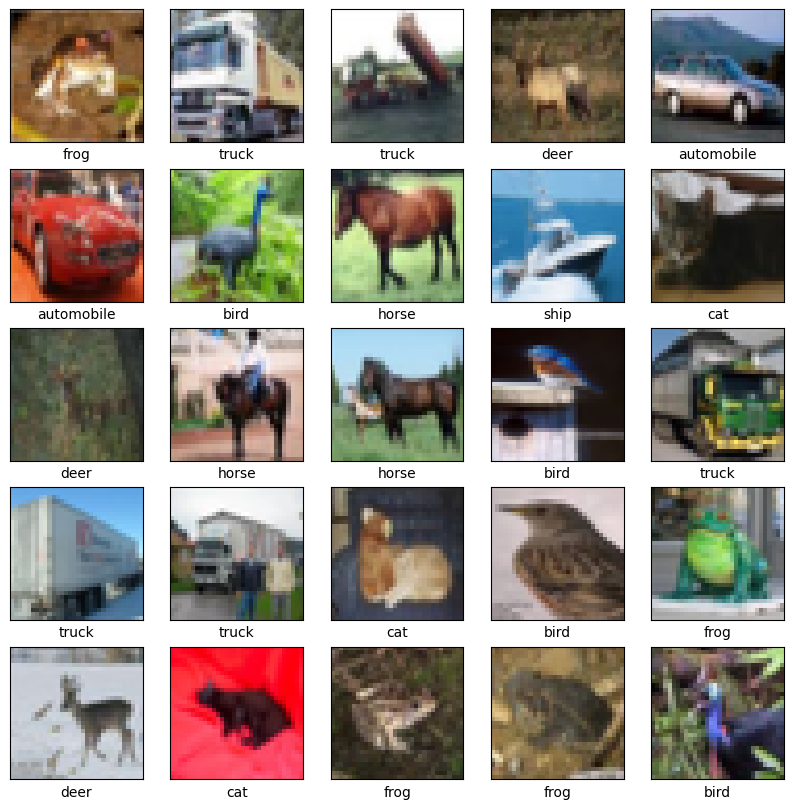

In [39]:
plt.figure(figsize=(10,10))
for i in range(25):
    plt.subplot(5,5, i+1)
    plt.xticks([])
    plt.yticks([])
    plt.grid(False)
    plt.imshow(train_images[i])
    plt.xlabel(class_names[train_labels[i][0]])
plt.show()

In [40]:
train_images = train_images/255.0
test_images = test_images/255.0

In [41]:
model = models.Sequential()
model.add(layers.Conv2D(32, (3, 3), activation='relu', input_shape=(32,32,3)))
model.add(layers.MaxPooling2D(2))
model.add(layers.Conv2D(64,(3,3), activation='relu'))
model.add(layers.MaxPooling2D(2))
model.add(layers.Conv2D(64,(3,3), activation='relu'))
model.add(Flatten())
model.add(Dense(64, activation='relu'))
model.add(Dense(10, activation='softmax'))
model.summary()

Model: "sequential_4"
_________________________________________________________________
 Layer (type)                Output Shape              Param #   
 conv2d_7 (Conv2D)           (None, 30, 30, 32)        896       
                                                                 
 max_pooling2d_5 (MaxPoolin  (None, 15, 15, 32)        0         
 g2D)                                                            
                                                                 
 conv2d_8 (Conv2D)           (None, 13, 13, 64)        18496     
                                                                 
 max_pooling2d_6 (MaxPoolin  (None, 6, 6, 64)          0         
 g2D)                                                            
                                                                 
 conv2d_9 (Conv2D)           (None, 4, 4, 64)          36928     
                                                                 
 flatten_5 (Flatten)         (None, 1024)             

In [42]:
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])
model.fit(train_images, train_labels, epochs=10)

Epoch 1/10
1563/1563 [==============================] - 27s 17ms/step - loss: 1.5427 - accuracy: 0.4339
Epoch 2/10
1563/1563 [==============================] - 19s 12ms/step - loss: 1.1672 - accuracy: 0.5865
Epoch 3/10
1563/1563 [==============================] - 18s 12ms/step - loss: 1.0063 - accuracy: 0.6448
Epoch 4/10
1563/1563 [==============================] - 10s 6ms/step - loss: 0.9116 - accuracy: 0.6803
Epoch 5/10
1563/1563 [==============================] - 24s 15ms/step - loss: 0.8415 - accuracy: 0.7058
Epoch 6/10
1563/1563 [==============================] - 23s 15ms/step - loss: 0.7873 - accuracy: 0.7240
Epoch 7/10
1563/1563 [==============================] - 32s 20ms/step - loss: 0.7351 - accuracy: 0.7420
Epoch 8/10
1563/1563 [==============================] - 28s 18ms/step - loss: 0.6956 - accuracy: 0.7553
Epoch 9/10
1563/1563 [==============================] - 23s 15ms/step - loss: 0.6565 - accuracy: 0.7704
Epoch 10/10
1563/1563 [==============================] - 26s 16ms

In [44]:
test_loss, test_acc = model.evaluate(test_images, test_labels)
print('Test loss:', test_loss)
print('Test accuracy:',test_acc)

313/313 [==============================] - 3s 11ms/step - loss: 0.8889 - accuracy: 0.7057
Test loss: 0.8888840675354004
Test accuracy: 0.7056999802589417


In [45]:
predictions = model.predict(test_images)

313/313 [==============================] - 2s 7ms/step


In [46]:
predictions.shape

(10000, 10)

In [49]:
predictions[0]

array([1.0824436e-03, 2.3088254e-04, 2.3039449e-03, 9.2610079e-01,
       4.4335052e-04, 2.8494317e-02, 3.9966673e-02, 1.0176514e-04,
       2.2744224e-04, 1.0484547e-03], dtype=float32)

In [50]:
test_labels[0]

array([3], dtype=uint8)

In [52]:
def plot_image(i, predictions_array, true_label, img):
    predictions_array, true_label, img = predictions_array[i], true_label[i], img[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    plt.imshow(img, cmap=plt.cm.binary)

    predicted_label = np.argmax(predictions_array)
    if predicted_label == true_label:
        color = 'blue'
    else:
        color = 'red'

    plt.xlabel("{} {:2.0f}% ({})".format(class_names[predicted_label],
                                        100 * np.max(predictions_array),
                                        class_names[true_label[0]]),
                                        color=color)

In [53]:
def plot_value_array(i, predictions_array, true_label):
    predictions_array, true_label = predictions_array[i], true_label[i]
    plt.grid(False)
    plt.xticks([])
    plt.yticks([])
    thisplot = plt.bar(range(10), predictions_array, color="#777777")
    plt.ylim([0,1])
    predicted_label = np.argmax(predictions_array)
    thisplot[predicted_label].set_color("red")
    thisplot[true_label[0]].set_color("blue")

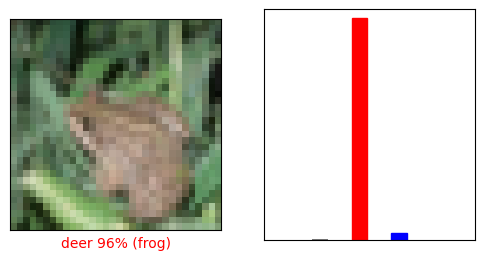

In [67]:
i = 4
plt.figure(figsize=(6,3))
plt.subplot(1,2,1)
plot_image(i, predictions, test_labels, test_images)
plt.subplot(1,2,2)
plot_value_array(i, predictions, test_labels)
plt.show()